[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/subramanyanaik/schoolofai_subbu/blob/main/assignment9/loss_harness.ipynb)

Generated from [`loss_harness.py`](loss_harness.py) by `tools/build_notebook.py` - edit the `.py`, not this file.

# Session 9 — Loss Functions & Output Heads

**A correct, observable next-token loss harness, and a second head that predicts `t+2`.**

The assignment starts from three lines that look finished and are not:

```python
hidden = model(tokens)
logits = output_head(hidden)
loss   = cross_entropy(
    logits[:, :-1].reshape(-1, vocab_size),
    tokens[:, 1:].reshape(-1),
)
```

Everything below makes those three lines *correct* and, more importantly, *observable*:
every shape is printed with the meaning of each axis, the shift is verified by reading
**strings** rather than integers, padding and document boundaries are masked and the
contributing-token count is shown changing, perplexity at initialisation is checked against
the vocabulary size, tied and untied heads are counted, and a hand-written chunked
cross-entropy is measured against the ordinary one.

This file is the single source of truth. `tools/build_notebook.py` converts it, cell for
cell, into `loss_harness.ipynb`, so the notebook and the script cannot drift apart.

Verified by executing this notebook end to end with nbclient on a local CUDA GPU
(RTX 3050, torch 2.5.1+cu121): 22 of 22 code cells, in order, zero error outputs. It has
not been run on Colab itself. The two Colab-specific paths -- installing tiktoken and
downloading the corpus -- are exercised separately, and the CUDA-absent path reports
analytic bytes instead of measured ones rather than failing. On a CPU runtime the four
training runs would take hours; use a GPU runtime.

In [1]:
# ---------------------------------------------------------------------------------------
# Setup.  The only non-stdlib requirements are torch, numpy, tiktoken and matplotlib,
# all of which are already present on Colab except tiktoken.
# ---------------------------------------------------------------------------------------
import json
import math
import os
import subprocess
import sys
import time
import urllib.request
from dataclasses import dataclass, asdict

try:
    import tiktoken
except ImportError:  # Colab
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tiktoken"], check=True)
    import tiktoken

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
IN_NOTEBOOK = "ipykernel" in sys.modules
if not IN_NOTEBOOK:                       # headless script run
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def show(fig):
    """Display inline in a notebook; close silently in a headless script run."""
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(fig)


RESULTS = {}          # every number the write-up quotes ends up in here

try:                                    # running as a script
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:                       # running as a notebook
    HERE = os.getcwd()
OUT_DIR = os.path.join(HERE, "results")
os.makedirs(OUT_DIR, exist_ok=True)


def rule(title):
    print("\n" + "=" * 88)
    print(title)
    print("=" * 88)


def record(key, value):
    RESULTS[key] = value
    return value


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 1337
torch.manual_seed(SEED)
np.random.seed(SEED)

rule("Environment")
print(f"python        : {sys.version.split()[0]}")
print(f"torch         : {torch.__version__}")
print(f"device        : {device}")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"gpu           : {props.name}  ({props.total_memory / 2**30:.2f} GiB)")
    record("gpu", props.name)
    record("gpu_total_gib", round(props.total_memory / 2**30, 2))
else:
    record("gpu", None)
record("torch_version", torch.__version__)
record("seed", SEED)


Environment
python        : 3.12.6
torch         : 2.5.1+cu121
device        : cuda
gpu           : NVIDIA GeForce RTX 3050 Laptop GPU  (4.00 GiB)


1337

In [2]:
# ---------------------------------------------------------------------------------------
# Tokenizer and configuration.
#
# The vocabulary is the real GPT-2 BPE vocabulary (50,257).  It is not the 131,072 of the
# V5 design discussion, but it is *our* vocabulary, which is what the perplexity anchor in
# item 5 has to be checked against.  Wherever the session's own numbers matter (item 6, and
# the projection table in item 7) the V5 configuration is reported alongside.
# ---------------------------------------------------------------------------------------
enc = tiktoken.get_encoding("gpt2")
VOCAB_SIZE = enc.n_vocab                 # 50257
EOT = enc.eot_token                      # 50256, doubles as PAD on the input side
IGNORE = -100                            # the target-side "this position does not count"

# The V5 configuration from the session, for comparison only.
V5_VOCAB, V5_DMODEL = 131_072, 4_096


@dataclass
class Config:
    vocab_size: int = VOCAB_SIZE
    d_model: int = 256
    n_layer: int = 4
    n_head: int = 4
    d_ff: int = 688          # SwiGLU, ~2.7x d_model, a multiple of 16
    rope_base: float = 10_000.0
    tie_head: bool = False


cfg = Config()

rule("Configuration")
for k, v in asdict(cfg).items():
    print(f"{k:<12}: {v}")
print(f"{'eot/pad id':<12}: {EOT}")
print(f"{'ignore_index':<12}: {IGNORE}")
print(f"\nln(V) = ln({VOCAB_SIZE}) = {math.log(VOCAB_SIZE):.4f}   <- the loss an untrained model must start at")
record("vocab_size", VOCAB_SIZE)
record("d_model", cfg.d_model)
record("n_layer", cfg.n_layer)
record("n_head", cfg.n_head)
record("d_ff", cfg.d_ff)
record("ln_vocab", round(math.log(VOCAB_SIZE), 4))


def tok_str(token_id):
    """One token id as a printable string.  Bytes, not `decode`, so that a token which is
    half a UTF-8 character shows up as a replacement char instead of silently vanishing."""
    if token_id == IGNORE:
        return "<masked>"
    return repr(enc.decode_single_token_bytes(int(token_id)).decode("utf-8", "replace"))


Configuration
vocab_size  : 50257
d_model     : 256
n_layer     : 4
n_head      : 4
d_ff        : 688
rope_base   : 10000.0
tie_head    : False
eot/pad id  : 50256
ignore_index: -100

ln(V) = ln(50257) = 10.8249   <- the loss an untrained model must start at


In [3]:
# ---------------------------------------------------------------------------------------
# Data.  Tiny Shakespeare, tokenized with GPT-2 BPE.  Small enough that the whole notebook
# finishes in a few minutes, real enough that the loss curves mean something.
# ---------------------------------------------------------------------------------------
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = os.path.join(OUT_DIR, "tinyshakespeare.txt")

if not os.path.exists(DATA_PATH):
    with urllib.request.urlopen(DATA_URL, timeout=60) as r:
        open(DATA_PATH, "wb").write(r.read())

text = open(DATA_PATH, "r", encoding="utf-8").read()
all_ids = np.array(enc.encode(text), dtype=np.int64)
n_train = int(0.9 * len(all_ids))
train_ids = torch.from_numpy(all_ids[:n_train])
val_ids = torch.from_numpy(all_ids[n_train:])

rule("Data")
print(f"characters    : {len(text):,}")
print(f"tokens        : {len(all_ids):,}   (train {len(train_ids):,} / val {len(val_ids):,})")
print(f"chars/token   : {len(text) / len(all_ids):.2f}")
record("train_tokens", int(len(train_ids)))
record("val_tokens", int(len(val_ids)))


def get_batch(split, batch_size, seq_len, generator=None):
    src = train_ids if split == "train" else val_ids
    ix = torch.randint(len(src) - seq_len - 2, (batch_size,), generator=generator)
    x = torch.stack([src[i:i + seq_len] for i in ix])
    return x.to(device)


Data
characters    : 1,115,394
tokens        : 338,025   (train 304,222 / val 33,803)
chars/token   : 3.30


## The model

A small pre-norm decoder built the way Session 9 §2 describes it: RMSNorm on the branch,
SwiGLU in the feed-forward, RoPE inside attention, and a residual stream that nothing
ever writes over.

The **trunk** and the **output head** are deliberately separate objects, because the
assignment's snippet separates them, and because items 6 and 7 are entirely about the
head: `hidden = trunk(tokens)` then `logits = head(hidden)`.

In [4]:
class RMSNorm(nn.Module):
    """x / rms(x) * g.  No centring, no bias — Session 9 §2."""

    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.g = nn.Parameter(torch.ones(d))
        self.eps = eps

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.g


def rope_tables(seq_len, head_dim, base, device, dtype=torch.float32):
    inv = 1.0 / (base ** (torch.arange(0, head_dim, 2, device=device, dtype=dtype) / head_dim))
    t = torch.arange(seq_len, device=device, dtype=dtype)
    freqs = torch.outer(t, inv)                       # [T, head_dim/2]
    return freqs.cos(), freqs.sin()


def apply_rope(x, cos, sin):
    # x: [B, n_head, T, head_dim]
    x1, x2 = x[..., 0::2], x[..., 1::2]
    c, s = cos[None, None], sin[None, None]
    return torch.stack([x1 * c - x2 * s, x1 * s + x2 * c], dim=-1).flatten(-2)


class Attention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.n_head = cfg.n_head
        self.head_dim = cfg.d_model // cfg.n_head
        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.o = nn.Linear(cfg.d_model, cfg.d_model, bias=False)

    def forward(self, x, cos, sin, trace=None):
        B, T, D = x.shape
        q, k, v = self.qkv(x).split(D, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        if trace is not None:
            trace("q / k / v (each)", q, "B sequences | H heads | T positions | head_dim = D/H, this head's slice")
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        if trace is not None:
            trace("attention out", y, "B | H | T | head_dim — each position's mix of the values at or before it")
        y = y.transpose(1, 2).reshape(B, T, D)
        return self.o(y)


class SwiGLU(nn.Module):
    """down(silu(gate(x)) * up(x)) — three matrices, one of which is a gate."""

    def __init__(self, cfg):
        super().__init__()
        self.gate = nn.Linear(cfg.d_model, cfg.d_ff, bias=False)
        self.up = nn.Linear(cfg.d_model, cfg.d_ff, bias=False)
        self.down = nn.Linear(cfg.d_ff, cfg.d_model, bias=False)

    def forward(self, x, trace=None):
        g, u = self.gate(x), self.up(x)
        if trace is not None:
            trace("ffn gate / up (each)", g, "B | T | d_ff — the wide middle; one branch decides what passes")
        return self.down(F.silu(g) * u)


class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.n1, self.attn = RMSNorm(cfg.d_model), Attention(cfg)
        self.n2, self.ffn = RMSNorm(cfg.d_model), SwiGLU(cfg)

    def forward(self, x, cos, sin, trace=None):
        x = x + self.attn(self.n1(x), cos, sin, trace)      # pre-norm: the norm sits on the branch
        x = x + self.ffn(self.n2(x), trace)                 # nothing ever overwrites x
        return x


class Trunk(nn.Module):
    """tokens -> hidden.  Everything except the output head."""

    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.embed = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.norm_f = RMSNorm(cfg.d_model)
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, std=0.02)

    def forward(self, tokens, trace=None):
        B, T = tokens.shape
        cos, sin = rope_tables(T, self.cfg.d_model // self.cfg.n_head,
                               self.cfg.rope_base, tokens.device)
        x = self.embed(tokens)
        if trace is not None:
            trace("embed(tokens)", x, "B sequences | T positions | D = d_model, the residual stream enters")
        for i, blk in enumerate(self.blocks):
            x = blk(x, cos, sin, trace if i == 0 else None)
            if trace is not None and i == 0:
                trace("block 0 output", x, "B | T | D — same shape in, same shape out: that is the residual stream")
        x = self.norm_f(x)
        if trace is not None:
            trace("hidden", x, "B | T | D — one vector per position, having seen the whole context before it")
        return x


class OutputHead(nn.Module):
    """hidden -> logits.  One learned row per vocabulary token; z = h @ W.T"""

    def __init__(self, cfg, tied_to=None):
        super().__init__()
        if tied_to is not None:
            self.weight = tied_to.weight            # the *same* tensor, not a copy
            self.tied = True
        else:
            self.weight = nn.Parameter(torch.empty(cfg.vocab_size, cfg.d_model))
            nn.init.normal_(self.weight, std=0.02)
            self.tied = False

    def forward(self, hidden):
        return F.linear(hidden, self.weight)


def build(cfg, tie=False, seed=SEED):
    torch.manual_seed(seed)
    trunk = Trunk(cfg).to(device)
    head = OutputHead(cfg, tied_to=trunk.embed if tie else None).to(device)
    return trunk, head


trunk, head = build(cfg)                 # this pair stays UNTRAINED for the whole of Part 1
n_trunk = sum(p.numel() for p in trunk.parameters())
n_head_params = head.weight.numel()

rule("Model")
print(f"trunk parameters : {n_trunk:>12,}")
print(f"head  parameters : {n_head_params:>12,}")
print(f"total (untied)   : {n_trunk + n_head_params:>12,}")


Model
trunk parameters :   16,030,208
head  parameters :   12,865,792
total (untied)   :   28,896,000


---
# Part 1 — the harness

## Item 1 — every tensor shape, and what each dimension is

The trace below is the full path from token ids to a single scalar. The intermediate
tensors inside the block are printed for **block 0 only**; the other three are identical
in shape, which is the point of a residual stream.

The one to stare at is `logits`: `[B, T, V]` against `hidden`'s `[B, T, D]`. At this
configuration that is a **196×** blow-up in the last axis, and it happens in the last
layer, after all the attention work is done.

In [5]:
B_DEMO, T_DEMO = 2, 64
demo_tokens = get_batch("train", B_DEMO, T_DEMO, generator=torch.Generator().manual_seed(0))

_rows = []


def trace(name, t, meaning):
    _rows.append((name, tuple(t.shape), meaning))


rule("Item 1 — shapes, and what each dimension means")
with torch.no_grad():
    trace("tokens", demo_tokens, "B sequences | T positions — token ids, the model's only input")
    hidden = trunk(demo_tokens, trace=trace)
    logits = head(hidden)
    trace("logits", logits, "B | T | V — one raw unnormalised score per vocabulary token")

    shifted_logits = logits[:, :-1]
    trace("logits[:, :-1]", shifted_logits, "B | T-1 | V — drop the last position: nothing follows it")
    shifted_targets = demo_tokens[:, 1:]
    trace("tokens[:, 1:]", shifted_targets, "B | T-1 — drop the first token: nothing predicts it")

    flat_logits = shifted_logits.reshape(-1, VOCAB_SIZE)
    trace("flat logits", flat_logits, "B*(T-1) prediction sites | V scores each")
    flat_targets = shifted_targets.reshape(-1)
    trace("flat targets", flat_targets, "B*(T-1) — one correct token id per site")

    loss = F.cross_entropy(flat_logits, flat_targets)
    trace("loss", loss, "scalar — the mean surprise, in nats, over every contributing site")

w = max(len(r[0]) for r in _rows)
for name, shape, meaning in _rows:
    print(f"{name:<{w}}  {str(list(shape)):<22}  {meaning}")

print(f"\nB = {B_DEMO} sequences, T = {T_DEMO} positions, D = {cfg.d_model}, "
      f"H = {cfg.n_head} heads, head_dim = {cfg.d_model // cfg.n_head}, V = {VOCAB_SIZE}")
print(f"hidden holds {hidden.numel():,} numbers; logits holds {logits.numel():,} — "
      f"a factor of V/D = {VOCAB_SIZE / cfg.d_model:.1f}x, created in the last layer")
print(f"contributing sites: B*(T-1) = {flat_targets.numel()}")
print(f"loss = {loss.item():.4f} nats")
record("item1_hidden_numel", int(hidden.numel()))
record("item1_logits_numel", int(logits.numel()))
record("item1_blowup", round(VOCAB_SIZE / cfg.d_model, 1))


Item 1 — shapes, and what each dimension means


tokens                [2, 64]                 B sequences | T positions — token ids, the model's only input
embed(tokens)         [2, 64, 256]            B sequences | T positions | D = d_model, the residual stream enters
q / k / v (each)      [2, 4, 64, 64]          B sequences | H heads | T positions | head_dim = D/H, this head's slice
attention out         [2, 4, 64, 64]          B | H | T | head_dim — each position's mix of the values at or before it
ffn gate / up (each)  [2, 64, 688]            B | T | d_ff — the wide middle; one branch decides what passes
block 0 output        [2, 64, 256]            B | T | D — same shape in, same shape out: that is the residual stream
hidden                [2, 64, 256]            B | T | D — one vector per position, having seen the whole context before it
logits                [2, 64, 50257]          B | T | V — one raw unnormalised score per vocabulary token
logits[:, :-1]        [2, 63, 50257]          B | T-1 | V — drop the last position: no

196.3

## Item 2 — verify the shift by reading strings, not integers

This is the check the assignment is really about. The table prints, for one sequence,
the token the model is *given* beside the token it is *asked for*. Read down the two
columns: the target column must be the input column moved up by exactly one row.

Underneath it, the same table with the shift applied in the wrong direction. The
integers would look equally plausible; the strings do not.

In [6]:
rule("Item 2 — inputs beside targets, as strings")

seq = demo_tokens[0]
inp_ids = seq[:-1]
tgt_ids = seq[1:]

print("CORRECT SHIFT  —  target[i] is the token that follows input[i]\n")
print(f"{'pos':>4}  {'input token (given)':<24}  {'target token (asked for)':<24}")
print(f"{'-'*4}  {'-'*24}  {'-'*24}")
for i in range(18):
    print(f"{i:>4}  {tok_str(inp_ids[i]):<24}  {tok_str(tgt_ids[i]):<24}")

print("\nreconstructed input  :", repr(enc.decode(inp_ids[:18].tolist())))
print("reconstructed target :", repr(enc.decode(tgt_ids[:18].tolist())))

# The assertion that the strings are only illustrating.
assert torch.equal(inp_ids[1:], tgt_ids[:-1]), "targets are not the inputs advanced by one"
print("\nassert inp[1:] == tgt[:-1]  ->  OK: the target stream is the input stream advanced by one")

print()
print()
print("WRONG SHIFT  --  the forgot-to-shift bug: target[i] IS input[i]")
print()
print(f"{'pos':>4}  {'input token (given)':<24}  {'target token (asked for)':<24}")
print(f"{'-'*4}  {'-'*24}  {'-'*24}")
for i in range(8):
    print(f"{i:>4}  {tok_str(seq[i]):<24}  {tok_str(seq[i]):<24}  <-- identical")
print()
print("Read it: every row asks the model for a token it has already been handed.  The hidden")
print("state at position i has seen token i, so this is a copy task.  Nothing raises, no shape")
print("mismatch, no exception -- the loss simply becomes beautiful.  Part 3 trains it and plots it.")
record("item2_shift_verified", True)


Item 2 — inputs beside targets, as strings
CORRECT SHIFT  —  target[i] is the token that follows input[i]

 pos  input token (given)       target token (asked for)
----  ------------------------  ------------------------
   0  ' the'                    ' sins'                 
   1  ' sins'                   ' of'                   
   2  ' of'                     ' your'                 
   3  ' your'                   ' youth'                
   4  ' youth'                  '\n'                    
   5  '\n'                      'are'                   
   6  'are'                     ' forgiven'             
   7  ' forgiven'               ' you'                  
   8  ' you'                    ','                     
   9  ','                       ' you'                  
  10  ' you'                    "'re"                   
  11  "'re"                     ' well'                 
  12  ' well'                   ' to'                   
  13  ' to'                     ' liv

True

## Shared helpers: the loss, and a training loop

`ce_loss` returns the scalar **and the number of positions that actually contributed**,
because the second number is the one that catches mistakes. `F.cross_entropy` with
`ignore_index` already divides by the count of non-ignored targets, which is the correct
denominator — not `B*T`.

In [7]:
def ce_loss(logits, targets, ignore_index=IGNORE):
    """Mean cross-entropy over contributing positions, plus that count."""
    flat_logits = logits.reshape(-1, logits.shape[-1])
    flat_targets = targets.reshape(-1)
    n = int((flat_targets != ignore_index).sum())
    loss = F.cross_entropy(flat_logits, flat_targets, ignore_index=ignore_index)
    return loss, n


def per_token_ce(logits, targets, ignore_index=IGNORE):
    """The individual -log p(correct) terms, so we can look at one position on its own."""
    return F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]), targets.reshape(-1),
        ignore_index=ignore_index, reduction="none",
    )


def run_training(step_fn, params, steps, lr=1e-3, log_every=100, label="", eval_fn=None):
    opt = torch.optim.AdamW(params, lr=lr, betas=(0.9, 0.95), weight_decay=0.1)
    history = []
    t0 = time.time()
    for step in range(1, steps + 1):
        stats = step_fn(step)
        opt.zero_grad(set_to_none=True)
        stats["loss"].backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        opt.step()
        if step == 1 or step % log_every == 0 or step == steps:
            row = {"step": step, **{k: float(v) for k, v in stats.items() if k != "loss"},
                   "loss": float(stats["loss"])}
            if eval_fn is not None:
                row.update({k: float(v) for k, v in eval_fn().items()})
            history.append(row)
            cols = "  ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}"
                             for k, v in row.items() if k != "step")
            print(f"  [{label}] step {step:>4}/{steps}  {cols}")
    print(f"  [{label}] {steps} steps in {time.time() - t0:.1f}s")
    return history

## Item 3 — mask the padding, and watch the contributing-token count change

Four documents of different lengths, packed into a `[4, T]` batch and padded with
`<|endoftext|>`. Two ways to build the target tensor:

* **counted** — the raw shift, padding included. Every one of `B*(T-1)` positions counts.
* **masked** — padding targets replaced by `ignore_index = -100`. Only real tokens count.

The count is the number to read. The loss difference at initialisation is small — an
untrained model is equally bad at everything — so the second half of this section trains
a model *with padding counted* and shows what that actually buys you.

In [8]:
rule("Item 3 — padding")

pad_docs = [
    "The capital of India is New Delhi.",
    "Attention moves information between tokens; the feed-forward network is where each token thinks on its own.",
    "Softmax turns differences into ratios.",
    "A padding token is not a prediction, and a loss that counts it is lying to you about how well the model is doing.",
]
pad_ids = [enc.encode(d) for d in pad_docs]
T_PAD = max(len(x) for x in pad_ids)
lengths = torch.tensor([len(x) for x in pad_ids])

padded = torch.full((len(pad_ids), T_PAD), EOT, dtype=torch.long)
for b, ids in enumerate(pad_ids):
    padded[b, :len(ids)] = torch.tensor(ids)
padded = padded.to(device)
is_real = (torch.arange(T_PAD, device=device)[None, :] < lengths.to(device)[:, None])

print(f"batch shape           : {list(padded.shape)}   (B={len(pad_ids)} docs, T={T_PAD} positions)")
print(f"real token lengths    : {lengths.tolist()}   -> {int(lengths.sum())} real tokens, "
      f"{padded.numel() - int(lengths.sum())} pads")

inputs_p = padded[:, :-1]
targets_counted = padded[:, 1:].clone()                       # padding counted
targets_masked = padded[:, 1:].clone()
targets_masked[~is_real[:, 1:]] = IGNORE                      # padding masked out

with torch.no_grad():
    logits_p = head(trunk(inputs_p))
loss_counted, n_counted = ce_loss(logits_p, targets_counted)
loss_masked, n_masked = ce_loss(logits_p, targets_masked)

print(f"\n{'':<26}{'contributing tokens':>21}{'loss':>12}{'perplexity':>14}")
print(f"{'padding counted':<26}{n_counted:>21,}{loss_counted.item():>12.4f}"
      f"{math.exp(loss_counted.item()):>14,.1f}")
print(f"{'padding masked':<26}{n_masked:>21,}{loss_masked.item():>12.4f}"
      f"{math.exp(loss_masked.item()):>14,.1f}")
print(f"{'change':<26}{n_masked - n_counted:>21,}{loss_masked.item() - loss_counted.item():>12.4f}")
print(f"\nB*(T-1) = {padded.shape[0] * (T_PAD - 1)} positions exist; only {n_masked} of them are "
      f"real predictions.  {100 * (1 - n_masked / n_counted):.1f}% of the naive denominator is padding.")

record("item3_tokens_counted", n_counted)
record("item3_tokens_masked", n_masked)
record("item3_loss_counted_init", round(loss_counted.item(), 4))
record("item3_loss_masked_init", round(loss_masked.item(), 4))
record("item3_pad_fraction_pct", round(100 * (1 - n_masked / n_counted), 1))


Item 3 — padding
batch shape           : [4, 26]   (B=4 docs, T=26 positions)
real token lengths    : [8, 21, 7, 26]   -> 62 real tokens, 42 pads

                            contributing tokens        loss    perplexity
padding counted                             100     10.7900      48,534.4
padding masked                               58     10.9393      56,349.0
change                                      -42      0.1493

B*(T-1) = 100 positions exist; only 58 of them are real predictions.  42.0% of the naive denominator is padding.


42.0

### Item 3b — what counting the padding actually buys you

Random spans of Shakespeare, random lengths, padded to a fixed `T`. The model is trained
on the **counted** loss — padding included, exactly the bug. At every log point both
numbers are reported on the same batch: the counted loss the optimiser sees, and the
masked loss on real tokens only, which is the number that was ever worth anything.

In [9]:
rule("Item 3b — training with padding counted")

T_PADTRAIN, B_PADTRAIN = 128, 8
pad_gen = torch.Generator().manual_seed(7)


def padded_batch(generator):
    lens = torch.randint(20, T_PADTRAIN, (B_PADTRAIN,), generator=generator)
    starts = torch.randint(len(train_ids) - T_PADTRAIN - 2, (B_PADTRAIN,), generator=generator)
    x = torch.full((B_PADTRAIN, T_PADTRAIN), EOT, dtype=torch.long)
    for b in range(B_PADTRAIN):
        L = int(lens[b])
        x[b, :L] = train_ids[starts[b]:starts[b] + L]
    x = x.to(device)
    real = (torch.arange(T_PADTRAIN, device=device)[None, :] < lens.to(device)[:, None])
    return x, real


pad_trunk, pad_head = build(cfg, seed=SEED + 1)
pad_params = list(pad_trunk.parameters()) + ([] if pad_head.tied else [pad_head.weight])


def pad_step(step):
    x, real = padded_batch(pad_gen)
    logits = pad_head(pad_trunk(x[:, :-1]))
    tgt_counted = x[:, 1:]
    loss, _ = ce_loss(logits, tgt_counted)
    with torch.no_grad():
        tgt_masked = tgt_counted.clone()
        tgt_masked[~real[:, 1:]] = IGNORE
        masked, _ = ce_loss(logits, tgt_masked)
    return {"loss": loss, "counted": loss.detach(), "masked_real_only": masked, "real_frac": real[:, 1:].float().mean()}


pad_hist = run_training(pad_step, pad_params, steps=400, lr=1e-3, log_every=50, label="pad-counted")

final = pad_hist[-1]
print(f"\nfinal counted loss (what the optimiser sees) : {final['counted']:.4f}"
      f"   ppl {math.exp(final['counted']):>10,.1f}")
print(f"final masked loss  (real tokens only)        : {final['masked_real_only']:.4f}"
      f"   ppl {math.exp(final['masked_real_only']):>10,.1f}")
print(f"gap                                          : {final['masked_real_only'] - final['counted']:.4f} nats")
print("\nThe counted loss falls fast because most of the batch is padding and padding is trivially")
print("predictable: after a pad, another pad.  The masked loss is the honest one, and it is the")
print("one that barely moved.  A run reported on the counted number looks like it is working.")

record("item3b_steps", 400)
record("item3b_final_counted", round(final["counted"], 4))
record("item3b_final_masked", round(final["masked_real_only"], 4))
record("item3b_gap", round(final["masked_real_only"] - final["counted"], 4))
record("item3b_real_frac", round(final["real_frac"], 4))
print(f"(on average only {100 * final['real_frac']:.0f}% of the positions in these batches are real "
      f"tokens; the rest is padding predicting padding)")


Item 3b — training with padding counted


  [pad-counted] step    1/400  counted=10.8832  masked_real_only=10.9351  real_frac=0.5925  loss=10.8832


  [pad-counted] step   50/400  counted=4.4000  masked_real_only=6.5926  real_frac=0.6614  loss=4.4000


  [pad-counted] step  100/400  counted=3.9912  masked_real_only=6.1179  real_frac=0.6467  loss=3.9912


  [pad-counted] step  150/400  counted=3.0961  masked_real_only=5.4978  real_frac=0.5571  loss=3.0961


  [pad-counted] step  200/400  counted=3.5669  masked_real_only=5.3110  real_frac=0.6654  loss=3.5669


  [pad-counted] step  250/400  counted=3.1539  masked_real_only=5.1167  real_frac=0.6102  loss=3.1539


  [pad-counted] step  300/400  counted=2.5030  masked_real_only=5.5144  real_frac=0.4478  loss=2.5030


  [pad-counted] step  350/400  counted=3.1121  masked_real_only=5.2997  real_frac=0.5807  loss=3.1121


  [pad-counted] step  400/400  counted=3.3281  masked_real_only=5.1966  real_frac=0.6348  loss=3.3281
  [pad-counted] 400 steps in 40.0s

final counted loss (what the optimiser sees) : 3.3281   ppl       27.9
final masked loss  (real tokens only)        : 5.1966   ppl      180.6
gap                                          : 1.8685 nats

The counted loss falls fast because most of the batch is padding and padding is trivially
predictable: after a pad, another pad.  The masked loss is the honest one, and it is the
one that barely moved.  A run reported on the counted number looks like it is working.
(on average only 63% of the positions in these batches are real tokens; the rest is padding predicting padding)


## A reference model, briefly trained

Items 4 needs a model that has actually learned something, because a randomly initialised
model is uniformly surprised and a document boundary would not stand out from anything
else. This trains one on clean, unpadded Shakespeare. `trunk`/`head` from Item 1 are left
untouched — Item 5 needs them pristine.

In [10]:
rule("Reference model - training on clean text")

REF_STEPS, REF_B, REF_T = 600, 8, 256
ref_trunk, ref_head = build(cfg, seed=SEED + 2)
ref_params = list(ref_trunk.parameters()) + ([] if ref_head.tied else [ref_head.weight])
ref_gen = torch.Generator().manual_seed(21)


def ref_step(step):
    x = get_batch("train", REF_B, REF_T, generator=ref_gen)
    logits = ref_head(ref_trunk(x[:, :-1]))
    loss, _ = ce_loss(logits, x[:, 1:])
    return {"loss": loss, "ppl": torch.exp(loss.detach())}


ref_hist = run_training(ref_step, ref_params, steps=REF_STEPS, lr=1e-3, log_every=100, label="reference")
record("ref_steps", REF_STEPS)
record("ref_final_loss", round(ref_hist[-1]["loss"], 4))


Reference model - training on clean text


  [reference] step    1/600  ppl=52832.2461  loss=10.8749


  [reference] step  100/600  ppl=212.0238  loss=5.3567


  [reference] step  200/600  ppl=115.1866  loss=4.7466


  [reference] step  300/600  ppl=101.8975  loss=4.6240


  [reference] step  400/600  ppl=93.7344  loss=4.5405


  [reference] step  500/600  ppl=110.6044  loss=4.7060


  [reference] step  600/600  ppl=54.1597  loss=3.9919
  [reference] 600 steps in 97.2s


3.9919

## Item 4 — pack two documents, mask the boundary

Two documents concatenated into one sequence. Exactly one prediction site straddles the
join: the last token of document A being asked to predict the first token of document B.
There is no relationship between those two tokens. Training on that pair teaches the model
that unrelated things follow each other.

The loss is reported before and after masking that single site, and the difference is then
reproduced from arithmetic, so the explanation is checked rather than asserted.

In [11]:
rule("Item 4 — packed documents and the boundary")

doc_a_ids = val_ids[100:160].tolist()
doc_b_ids = val_ids[9000:9060].tolist()
packed = torch.tensor(doc_a_ids + doc_b_ids, device=device)[None, :]     # [1, T]
len_a = len(doc_a_ids)

inputs_k = packed[:, :-1]
targets_all = packed[:, 1:].clone()
BOUNDARY = len_a - 1                      # target index whose input is A's last token

targets_boundary_masked = targets_all.clone()
targets_boundary_masked[0, BOUNDARY] = IGNORE

print(f"packed sequence : {list(packed.shape)}  = doc A ({len_a} tokens) + doc B ({len(doc_b_ids)} tokens)")
print(f"boundary site   : target index {BOUNDARY}  (input = last token of A, target = first token of B)")
print()
print("  ...end of document A :", repr(enc.decode(doc_a_ids[-12:])))
print("  start of document B  :", repr(enc.decode(doc_b_ids[:12])))
print()
print(f"  the pair being trained on: input {tok_str(inputs_k[0, BOUNDARY])}"
      f"  ->  target {tok_str(targets_all[0, BOUNDARY])}")

with torch.no_grad():
    logits_k = ref_head(ref_trunk(inputs_k))

loss_before, n_before = ce_loss(logits_k, targets_all)
loss_after, n_after = ce_loss(logits_k, targets_boundary_masked)
terms = per_token_ce(logits_k, targets_all)
boundary_term = terms[BOUNDARY].item()

print(f"\n{'':<34}{'contributing':>14}{'loss':>10}{'perplexity':>14}")
print(f"{'before masking the boundary':<34}{n_before:>14}{loss_before.item():>10.4f}"
      f"{math.exp(loss_before.item()):>14,.1f}")
print(f"{'after masking the boundary':<34}{n_after:>14}{loss_after.item():>10.4f}"
      f"{math.exp(loss_after.item()):>14,.1f}")
print(f"{'difference':<34}{n_after - n_before:>14}{loss_after.item() - loss_before.item():>10.4f}")

reconstructed = (loss_before.item() * n_before - boundary_term) / (n_after)
print(f"\nExplanation, checked rather than asserted:")
print(f"  the boundary site's own term  -log p(first token of B | last token of A) = {boundary_term:.4f} nats")
print(f"  mean of the other {n_after} terms = (loss_before*{n_before} - {boundary_term:.4f}) / {n_after}"
      f" = {reconstructed:.4f}")
print(f"  loss after masking                                                       = {loss_after.item():.4f}")
assert abs(reconstructed - loss_after.item()) < 1e-3, "the arithmetic does not reproduce the masked loss"
print("  -> match.  Masking removes exactly one term from the numerator and one from the denominator.")

mean_others = loss_after.item()
rank = int((terms > boundary_term).sum()) + 1
print()
print(f"  boundary term / mean of every other term = {boundary_term / mean_others:.2f}x"
      f"   (it ranks {rank} of {n_before} sites in this particular sequence)")
print("  One draw proves nothing, so the same measurement is repeated below over many pairs.")

record("item4_n_before", n_before)
record("item4_n_after", n_after)
record("item4_loss_before", round(loss_before.item(), 4))
record("item4_loss_after", round(loss_after.item(), 4))
record("item4_boundary_term", round(boundary_term, 4))
record("item4_boundary_ratio", round(boundary_term / mean_others, 2))

# --- the same measurement over many packed pairs, because one draw proves nothing -------
PAIRS, PAIR_B, DOC_LEN = 256, 16, 60
gpair = torch.Generator().manual_seed(11)
bnd_sum, int_sum, bnd_wins = 0.0, 0.0, 0
with torch.no_grad():
    for _ in range(PAIRS // PAIR_B):
        starts = torch.randint(len(val_ids) - DOC_LEN - 2, (PAIR_B, 2), generator=gpair)
        rows = [torch.cat([val_ids[a:a + DOC_LEN], val_ids[b:b + DOC_LEN]])
                for a, b in starts.tolist()]
        xb = torch.stack(rows).to(device)
        tb = per_token_ce(ref_head(ref_trunk(xb[:, :-1])), xb[:, 1:]).view(PAIR_B, -1)
        bnd = tb[:, DOC_LEN - 1]
        interior = torch.cat([tb[:, :DOC_LEN - 1], tb[:, DOC_LEN:]], dim=1).mean(dim=1)
        bnd_sum += bnd.sum().item()
        int_sum += interior.sum().item()
        bnd_wins += int((bnd > interior).sum())

mean_bnd, mean_int = bnd_sum / PAIRS, int_sum / PAIRS
print()
print(f"Over {PAIRS} independently packed document pairs:")
print(f"  mean loss at the boundary site  : {mean_bnd:.4f} nats")
print(f"  mean loss at every other site   : {mean_int:.4f} nats")
print(f"  ratio                           : {mean_bnd / mean_int:.2f}x")
print(f"  the boundary is worse than its own sequence average in "
      f"{100 * bnd_wins / PAIRS:.0f}% of pairs")
print()
print("So the boundary is genuinely harder, on average, and harder for a reason no amount of")
print("training can fix: nothing in document A predicts the first token of document B.")
print()
print("Now read what masking did to the *reported number*: almost nothing, because one site in")
print(f"{n_before} cannot move a mean.  That is the trap.  The damage is not to the scalar you")
print(f"print, it is to the gradient at that site -- a dense update over all {VOCAB_SIZE:,}")
print("vocabulary rows, teaching the model that unrelated things follow each other.  On a")
print("4,096-token packed sequence of ~200-token documents that is ~20 such updates per")
print("sequence, on every step, for the whole run.")

record("item4_pairs", PAIRS)
record("item4_mean_boundary", round(mean_bnd, 4))
record("item4_mean_interior", round(mean_int, 4))
record("item4_mean_ratio", round(mean_bnd / mean_int, 2))
record("item4_boundary_worse_pct", round(100 * bnd_wins / PAIRS, 1))


Item 4 — packed documents and the boundary
packed sequence : [1, 120]  = doc A (60 tokens) + doc B (60 tokens)
boundary site   : target index 59  (input = last token of A, target = first token of B)

  ...end of document A : ' shall a buzzard take thee?\n\nKATHAR'
  start of document B  : ' the\nhorses ran away, how her bridle was'

  the pair being trained on: input 'AR'  ->  target ' the'

                                    contributing      loss    perplexity
before masking the boundary                  119    5.4252         227.1
after masking the boundary                   118    5.4188         225.6
difference                                    -1   -0.0064

Explanation, checked rather than asserted:
  the boundary site's own term  -log p(first token of B | last token of A) = 6.1839 nats
  mean of the other 118 terms = (loss_before*119 - 6.1839) / 118 = 5.4188
  loss after masking                                                       = 5.4188
  -> match.  Masking removes exactl


Over 256 independently packed document pairs:
  mean loss at the boundary site  : 9.7383 nats
  mean loss at every other site   : 4.9676 nats
  ratio                           : 1.96x
  the boundary is worse than its own sequence average in 88% of pairs

So the boundary is genuinely harder, on average, and harder for a reason no amount of
training can fix: nothing in document A predicts the first token of document B.

Now read what masking did to the *reported number*: almost nothing, because one site in
119 cannot move a mean.  That is the trap.  The damage is not to the scalar you
print, it is to the gradient at that site -- a dense update over all 50,257
vocabulary rows, teaching the model that unrelated things follow each other.  On a
4,096-token packed sequence of ~200-token documents that is ~20 such updates per
sequence, on every step, for the whole run.


87.9

## Item 5 — perplexity at initialisation

`perplexity = exp(mean loss)`: how many equally likely options the model is effectively
choosing between at each token. An untrained model has no reason to prefer any token, so
it should sit at **V**, and the loss at **ln V**.

This uses the `trunk`/`head` pair from Item 1, which nothing has trained. It is the
cheapest sanity check in the session and it is checked here before anything else is
trusted.

In [12]:
rule("Item 5 — perplexity of an untrained model")

with torch.no_grad():
    x_eval = get_batch("val", 8, 256, generator=torch.Generator().manual_seed(5))
    logits_eval = head(trunk(x_eval[:, :-1]))
    init_loss, n_eval = ce_loss(logits_eval, x_eval[:, 1:])
init_ppl = math.exp(init_loss.item())
ln_v = math.log(VOCAB_SIZE)

print(f"positions evaluated       : {n_eval:,}")
print(f"loss at initialisation    : {init_loss.item():.4f} nats")
print(f"perplexity                : {init_ppl:>12,.1f}")
print(f"vocabulary size V         : {VOCAB_SIZE:>12,}")
print(f"ln(V)                     : {ln_v:.4f} nats")
print(f"loss / ln(V)              : {init_loss.item() / ln_v:.4f}")
print(f"perplexity / V            : {init_ppl / VOCAB_SIZE:.4f}")

# The exact anchor: a model whose logits are all equal is exactly ln(V), by construction.
uniform_loss = F.cross_entropy(torch.zeros(4, VOCAB_SIZE, device=device),
                               torch.zeros(4, dtype=torch.long, device=device)).item()
print(f"\nuniform-logits control    : {uniform_loss:.4f} nats  (exactly ln V, as it must be)")
assert abs(init_loss.item() - ln_v) < 0.35, "initialisation is not near ln(V) -- find the bug"
print(f"deviation from ln(V)      : {init_loss.item() - ln_v:+.4f} nats -> within tolerance, proceed.")
print("\nIf this had come out at, say, 4 nats, the target alignment would be wrong and every")
print("number after it would be worthless.  Part 3 shows exactly that failure with a curve.")

record("item5_init_loss", round(init_loss.item(), 4))
record("item5_init_ppl", round(init_ppl, 1))
record("item5_ppl_over_vocab", round(init_ppl / VOCAB_SIZE, 4))
record("item5_uniform_control", round(uniform_loss, 4))


Item 5 — perplexity of an untrained model
positions evaluated       : 2,040
loss at initialisation    : 10.8373 nats
perplexity                :     50,883.2
vocabulary size V         :       50,257
ln(V)                     : 10.8249 nats
loss / ln(V)              : 1.0011
perplexity / V            : 1.0125

uniform-logits control    : 10.8249 nats  (exactly ln V, as it must be)
deviation from ln(V)      : +0.0124 nats -> within tolerance, proceed.

If this had come out at, say, 4 nats, the target alignment would be wrong and every
number after it would be worthless.  Part 3 shows exactly that failure with a curve.


10.8249

## Item 6 — tied against untied head parameters

The head is `[V, D]`: one learned row per vocabulary token. The input embedding table is
`[V, D]` too, so tying uses one matrix for both reading tokens in and scoring them out.
The two models below are built identically except for that.

In [13]:
rule("Item 6 — tied vs untied head")

untied_trunk, untied_head = build(cfg, tie=False, seed=SEED)
tied_trunk, tied_head = build(cfg, tie=True, seed=SEED)


def count_params(trunk_, head_):
    seen, total = set(), 0
    for p in list(trunk_.parameters()) + [head_.weight]:
        if id(p) in seen:            # a tied head IS the embedding tensor, count it once
            continue
        seen.add(id(p))
        total += p.numel()
    return total


embed_params = cfg.vocab_size * cfg.d_model
body_params = sum(p.numel() for n, p in untied_trunk.named_parameters() if not n.startswith("embed"))
untied_total = count_params(untied_trunk, untied_head)
tied_total = count_params(tied_trunk, tied_head)

print(f"tied head shares storage with the embedding : {tied_head.weight.data_ptr() == tied_trunk.embed.weight.data_ptr()}")
print()
print(f"{'component':<34}{'parameters':>16}")
print(f"{'-'*34}{'-'*16}")
print(f"{'transformer body (4 blocks + norm)':<34}{body_params:>16,}")
print(f"{'input embedding  [V, D]':<34}{embed_params:>16,}")
print(f"{'output head      [V, D]':<34}{embed_params:>16,}")
print(f"{'-'*34}{'-'*16}")
print(f"{'UNTIED total':<34}{untied_total:>16,}")
print(f"{'TIED total':<34}{tied_total:>16,}")
print(f"{'saved by tying':<34}{untied_total - tied_total:>16,}"
      f"   ({100 * (untied_total - tied_total) / untied_total:.1f}% of the model)")
assert untied_total - tied_total == embed_params
print()
print(f"The head alone is {100 * embed_params / untied_total:.1f}% of the untied model, and the body "
      f"is only {100 * body_params / untied_total:.1f}%.")
print(f"At this width the two [V, D] matrices are {100 * 2 * embed_params / untied_total:.1f}% of every parameter in it.")

print(f"\nThe same arithmetic at the V5 configuration from the session (V={V5_VOCAB:,}, D={V5_DMODEL:,}):")
v5_head = V5_VOCAB * V5_DMODEL
print(f"  head [V, D]              : {v5_head:>15,}  ({v5_head / 1e6:.1f}M)")
print(f"  saved by tying           : {v5_head:>15,}")
print("  ...except that V5's input side is a byte codec plus one projection, which has no rows")
print("  to tie to.  Tying is the standard escape and it is closed; that is Session 9 section 8.")

record("item6_body_params", body_params)
record("item6_embed_params", embed_params)
record("item6_untied_total", untied_total)
record("item6_tied_total", tied_total)
record("item6_saved", untied_total - tied_total)
record("item6_saved_pct", round(100 * (untied_total - tied_total) / untied_total, 1))
record("item6_v5_head_params", v5_head)


Item 6 — tied vs untied head


tied head shares storage with the embedding : True

component                               parameters
--------------------------------------------------
transformer body (4 blocks + norm)       3,164,416
input embedding  [V, D]                 12,865,792
output head      [V, D]                 12,865,792
--------------------------------------------------
UNTIED total                            28,896,000
TIED total                              16,030,208
saved by tying                          12,865,792   (44.5% of the model)

The head alone is 44.5% of the untied model, and the body is only 11.0%.
At this width the two [V, D] matrices are 89.0% of every parameter in it.

The same arithmetic at the V5 configuration from the session (V=131,072, D=4,096):
  head [V, D]              :     536,870,912  (536.9M)
  saved by tying           :     536,870,912
  ...except that V5's input side is a byte codec plus one projection, which has no rows
  to tie to.  Tying is the standard escape and

536870912

## Item 7 — ordinary cross-entropy against a chunked one

The chunked version below is written from scratch as a `torch.autograd.Function`. The
forward pass walks the tokens in blocks, computes each block's logits, accumulates its
loss and **throws the logits away**. The backward pass recomputes each block's logits
when it needs them and forms `softmax(z) - onehot(y)` in place — the session's own
gradient — so the full `[N, V]` tensor never exists in either direction.

The arithmetic is identical. Only the memory traffic changes. That claim is checked
against `F.cross_entropy` on both the loss and both gradients before any memory number
is reported.

In [14]:
class ChunkedCrossEntropy(torch.autograd.Function):
    """Mean cross-entropy of `hidden @ weight.T` against `targets`, never materialising
    the full [N, V] logits tensor.  Peak logit memory is chunk_size * V instead of N * V."""

    @staticmethod
    def forward(ctx, hidden, weight, targets, chunk_size, ignore_index):
        N = hidden.shape[0]
        total = hidden.new_zeros((), dtype=torch.float32)
        count = 0
        for s in range(0, N, chunk_size):
            e = min(s + chunk_size, N)
            logits = (hidden[s:e] @ weight.t()).float()
            tgt = targets[s:e]
            total += F.cross_entropy(logits, tgt, reduction="sum", ignore_index=ignore_index)
            count += int((tgt != ignore_index).sum())
            del logits                                  # the whole point
        ctx.save_for_backward(hidden, weight, targets)
        ctx.chunk_size, ctx.ignore_index, ctx.count = chunk_size, ignore_index, max(count, 1)
        return total / ctx.count

    @staticmethod
    def backward(ctx, grad_out):
        hidden, weight, targets = ctx.saved_tensors
        cs, ignore_index, count = ctx.chunk_size, ctx.ignore_index, ctx.count
        grad_hidden = torch.zeros_like(hidden)
        grad_weight = torch.zeros_like(weight)
        scale = grad_out / count
        for s in range(0, hidden.shape[0], cs):
            e = min(s + cs, hidden.shape[0])
            h = hidden[s:e]
            logits = (h @ weight.t()).float()           # recomputed, not stored
            g = torch.softmax(logits, dim=-1)           # softmax(z) ...
            del logits                                  # ... and the logits are gone again
            tgt = targets[s:e]
            g[torch.arange(e - s, device=h.device), tgt.clamp_min(0)] -= 1.0   # ... - onehot(y)
            g.mul_((tgt != ignore_index).unsqueeze(1)).mul_(scale)             # in place
            g = g.to(hidden.dtype)
            grad_hidden[s:e] = g @ weight
            grad_weight += g.t() @ h
            del g
        return grad_hidden, grad_weight, None, None, None


def chunked_cross_entropy(hidden, weight, targets, chunk_size=1024, ignore_index=IGNORE):
    return ChunkedCrossEntropy.apply(hidden, weight, targets, chunk_size, ignore_index)

In [15]:
rule("Item 7 — correctness of the chunked loss, then memory")

# Free the duplicates from earlier sections so the measurement is not competing with them.
for _name in ["untied_trunk", "untied_head", "tied_trunk", "tied_head", "pad_trunk", "pad_head",
              "logits", "shifted_logits", "flat_logits", "logits_p", "logits_eval", "logits_k"]:
    globals().pop(_name, None)
if device.type == "cuda":
    torch.cuda.empty_cache()

N_MEM, D_MEM, CHUNK = 4096, cfg.d_model, 256
torch.manual_seed(3)
h_ref = torch.randn(N_MEM, D_MEM, device=device) * 0.5
w_ref = torch.randn(VOCAB_SIZE, D_MEM, device=device) * 0.02
t_ref = torch.randint(0, VOCAB_SIZE, (N_MEM,), device=device)
t_ref[::17] = IGNORE                                   # exercise the mask path too

# --- correctness ------------------------------------------------------------------------
ha = h_ref.clone().requires_grad_(True); wa = w_ref.clone().requires_grad_(True)
loss_naive = F.cross_entropy(ha @ wa.t(), t_ref, ignore_index=IGNORE)
loss_naive.backward()

hb = h_ref.clone().requires_grad_(True); wb = w_ref.clone().requires_grad_(True)
loss_chunk = chunked_cross_entropy(hb, wb, t_ref, chunk_size=CHUNK)
loss_chunk.backward()

d_loss = abs(loss_naive.item() - loss_chunk.item())
d_gh = (ha.grad - hb.grad).abs().max().item()
d_gw = (wa.grad - wb.grad).abs().max().item()
print(f"ordinary cross-entropy loss : {loss_naive.item():.10f}")
print(f"chunked   cross-entropy loss: {loss_chunk.item():.10f}")
print(f"|difference|                : {d_loss:.3e}")
print(f"max |d loss / d hidden| diff: {d_gh:.3e}   (scale {ha.grad.abs().max().item():.3e})")
print(f"max |d loss / d weight| diff: {d_gw:.3e}   (scale {wa.grad.abs().max().item():.3e})")
assert d_loss < 1e-5 and d_gh < 1e-6 and d_gw < 1e-6, "the chunked loss is not the same objective"
print("-> same objective, same gradients.  Only the memory traffic differs.")
record("item7_loss_naive", float(f"{loss_naive.item():.8f}"))
record("item7_loss_chunked", float(f"{loss_chunk.item():.8f}"))
record("item7_loss_absdiff", float(f"{d_loss:.3e}"))
record("item7_grad_absdiff", float(f"{max(d_gh, d_gw):.3e}"))

del ha, wa, hb, wb, loss_naive, loss_chunk
if device.type == "cuda":
    torch.cuda.empty_cache()


Item 7 — correctness of the chunked loss, then memory


ordinary cross-entropy loss : 10.8399400711
chunked   cross-entropy loss: 10.8399391174
|difference|                : 9.537e-07
max |d loss / d hidden| diff: 3.474e-10   (scale 2.716e-05)
max |d loss / d weight| diff: 1.368e-09   (scale 7.921e-04)
-> same objective, same gradients.  Only the memory traffic differs.


In [16]:
# --- peak memory ------------------------------------------------------------------------
def measure_peak(fn):
    """Peak *additional* bytes allocated by fn, over the allocation already standing."""
    if device.type != "cuda":
        return None, fn()
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    base = torch.cuda.memory_allocated()
    out = fn()
    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() - base
    del out
    torch.cuda.empty_cache()
    return peak, None


def naive_fwd_bwd():
    h = h_ref.clone().requires_grad_(True)
    w = w_ref.clone().requires_grad_(True)
    loss = F.cross_entropy(h @ w.t(), t_ref, ignore_index=IGNORE)
    loss.backward()
    return loss.item()


def chunked_fwd_bwd():
    h = h_ref.clone().requires_grad_(True)
    w = w_ref.clone().requires_grad_(True)
    loss = chunked_cross_entropy(h, w, t_ref, chunk_size=CHUNK)
    loss.backward()
    return loss.item()


MiB = 2 ** 20
peak_naive, _ = measure_peak(naive_fwd_bwd)
peak_chunked, _ = measure_peak(chunked_fwd_bwd)

logit_bytes = N_MEM * VOCAB_SIZE * 4
chunk_bytes = CHUNK * VOCAB_SIZE * 4

print(f"tokens N = {N_MEM:,}   D = {D_MEM}   V = {VOCAB_SIZE:,}   chunk = {CHUNK}   dtype = fp32")
print(f"one full [N, V] logits tensor is {logit_bytes / MiB:,.1f} MiB; one chunk is {chunk_bytes / MiB:,.1f} MiB\n")

if peak_naive is not None:
    ratio = peak_naive / peak_chunked
    print(f"{'implementation':<28}{'measured peak (forward+backward)':>34}")
    print(f"{'-'*28}{'-'*34}")
    print(f"{'ordinary cross-entropy':<28}{peak_naive / MiB:>27,.1f} MiB")
    print(f"{'chunked cross-entropy':<28}{peak_chunked / MiB:>27,.1f} MiB")
    print(f"{'ratio':<28}{ratio:>27,.1f}x")
    record("item7_peak_naive_mib", round(peak_naive / MiB, 1))
    record("item7_peak_chunked_mib", round(peak_chunked / MiB, 1))
    record("item7_ratio", round(ratio, 1))
    record("item7_measured", True)
else:
    print("No CUDA device: peak memory cannot be measured.  Analytic logit-tensor bytes only:")
    print(f"  ordinary : {logit_bytes / MiB:,.1f} MiB   chunked : {chunk_bytes / MiB:,.1f} MiB"
          f"   ratio {logit_bytes / chunk_bytes:.1f}x")
    record("item7_measured", False)
    record("item7_peak_naive_mib", round(logit_bytes / MiB, 1))
    record("item7_peak_chunked_mib", round(chunk_bytes / MiB, 1))
    record("item7_ratio", round(logit_bytes / chunk_bytes, 1))

record("item7_N", N_MEM)

record("item7_chunk", CHUNK)

print("\nThe measured ratio is smaller than the N/chunk ratio of "
      f"{N_MEM // CHUNK}x, and it should be: the chunked run still pays for `hidden` "
      f"({h_ref.numel() * 4 / MiB:.1f} MiB), for the head weight and its gradient "
      f"({2 * w_ref.numel() * 4 / MiB:,.1f} MiB), and those are fixed costs no chunking removes.")
print("What chunking removes is the part that scales with tokens times vocabulary.")

# --- what the chunk size actually buys --------------------------------------------------
if device.type == "cuda":
    print()
    print("Peak memory against chunk size, same objective every time:")
    print(f"{'chunk':>8}{'chunks':>9}{'peak (MiB)':>14}{'vs ordinary':>14}{'loss':>14}")
    print(f"{'-'*8}{'-'*9}{'-'*14}{'-'*14}{'-'*14}")
    sweep = []
    for cs in [64, 128, 256, 512, 1024, 2048]:
        def _run(cs=cs):
            h = h_ref.clone().requires_grad_(True)
            w = w_ref.clone().requires_grad_(True)
            out = chunked_cross_entropy(h, w, t_ref, chunk_size=cs)
            out.backward()
            return out.item()
        pk, _ = measure_peak(_run)
        val = _run()
        print(f"{cs:>8}{-(-N_MEM // cs):>9}{pk / MiB:>14,.1f}{peak_naive / pk:>13,.1f}x{val:>14.6f}")
        sweep.append({"chunk": cs, "peak_mib": round(pk / MiB, 1),
                      "ratio": round(peak_naive / pk, 1), "loss": round(val, 6)})
    record("item7_sweep", sweep)
    print()
    print("Every row is the same number to six decimals.  Smaller chunks buy memory and cost")
    print("python-level loop iterations.  Nothing about the objective changes.")


print(f"\nThe same arithmetic at the V5 configuration (V={V5_VOCAB:,}, bf16), Session 9 section 8:")
print(f"{'batch':>7}{'context':>10}{'tokens':>12}{'logits, bf16':>16}{'+backward':>13}{'chunked @1024':>16}")
for b, t in [(8, 8_192), (4, 32_768), (1, 262_144)]:
    tok = b * t
    full = tok * V5_VOCAB * 2
    print(f"{b:>7}{t:>10,}{tok:>12,}{full / 2**30:>13,.1f} GiB{2 * full / 2**30:>10,.1f} GiB"
          f"{1024 * V5_VOCAB * 2 / MiB:>12,.0f} MiB")
print("A 64 GiB intermediate whose only purpose is to be collapsed into one scalar.")

tokens N = 4,096   D = 256   V = 50,257   chunk = 256   dtype = fp32
one full [N, V] logits tensor is 785.3 MiB; one chunk is 49.1 MiB

implementation                measured peak (forward+backward)
--------------------------------------------------------------
ordinary cross-entropy                          2,412.0 MiB
chunked cross-entropy                             208.0 MiB
ratio                                              11.6x

The measured ratio is smaller than the N/chunk ratio of 16x, and it should be: the chunked run still pays for `hidden` (4.0 MiB), for the head weight and its gradient (98.2 MiB), and those are fixed costs no chunking removes.
What chunking removes is the part that scales with tokens times vocabulary.

Peak memory against chunk size, same objective every time:
   chunk   chunks    peak (MiB)   vs ordinary          loss
-----------------------------------------------------------


      64       64         170.3         14.2x     10.839940


     128       32         182.5         13.2x     10.839938


     256       16         208.0         11.6x     10.839939


     512        8         303.4          7.9x     10.839937


    1024        4         499.7          4.8x     10.839938


    2048        2         892.3          2.7x     10.839938

Every row is the same number to six decimals.  Smaller chunks buy memory and cost
python-level loop iterations.  Nothing about the objective changes.

The same arithmetic at the V5 configuration (V=131,072, bf16), Session 9 section 8:
  batch   context      tokens    logits, bf16    +backward   chunked @1024
      8     8,192      65,536         16.0 GiB      32.0 GiB         256 MiB
      4    32,768     131,072         32.0 GiB      64.0 GiB         256 MiB
      1   262,144     262,144         64.0 GiB     128.0 GiB         256 MiB
A 64 GiB intermediate whose only purpose is to be collapsed into one scalar.


---
# Part 2 — one extra head

A second output head on the same trunk, predicting token `t+2`. Both heads read the same
hidden state; head 1 is asked for the next token, head 2 for the one after that.

Alignment matters and is easy to get wrong, so both heads are scored on **the same set of
positions**, `0 … T-3`, which makes the two losses directly comparable:

| head | input positions | targets |
|---|---|---|
| 1 | `h[:, :-2]` | `tokens[:, 1:-1]` |
| 2 | `h[:, :-2]` | `tokens[:, 2:]` |

The losses simply add. Both use the chunked cross-entropy written in Item 7 — two dense
`[N, V]` heads at once is exactly the situation it exists for.

A single-head baseline is trained on identical data with an identical seed, so the effect
of the extra head on head 1 can be read off rather than guessed at.

In [17]:
rule("Part 2 — a second head predicting t+2")

MTP_STEPS, MTP_B, MTP_T, MTP_CHUNK = 800, 8, 256, 1024


def new_head(seed):
    torch.manual_seed(seed)
    h = OutputHead(cfg).to(device)
    return h


# --- the two-head model -------------------------------------------------------------
mtp_trunk, mtp_head1 = build(cfg, seed=SEED + 3)
mtp_head2 = new_head(SEED + 4)
mtp_params = list(mtp_trunk.parameters()) + [mtp_head1.weight, mtp_head2.weight]
mtp_gen = torch.Generator().manual_seed(42)


def mtp_step(step):
    x = get_batch("train", MTP_B, MTP_T, generator=mtp_gen)
    h = mtp_trunk(x)[:, :-2].reshape(-1, cfg.d_model)
    l1 = chunked_cross_entropy(h, mtp_head1.weight, x[:, 1:-1].reshape(-1), MTP_CHUNK)
    l2 = chunked_cross_entropy(h, mtp_head2.weight, x[:, 2:].reshape(-1), MTP_CHUNK)
    return {"loss": l1 + l2, "head1": l1.detach(), "head2": l2.detach(),
            "gap": (l2 - l1).detach()}


print("two-head model (t+1 and t+2):")
mtp_hist = run_training(mtp_step, mtp_params, steps=MTP_STEPS, lr=1e-3, log_every=100, label="mtp")

# --- the single-head baseline, same seed, same data order ------------------------------
base_trunk, base_head1 = build(cfg, seed=SEED + 3)
base_params = list(base_trunk.parameters()) + [base_head1.weight]
base_gen = torch.Generator().manual_seed(42)


def base_step(step):
    x = get_batch("train", MTP_B, MTP_T, generator=base_gen)
    h = base_trunk(x)[:, :-2].reshape(-1, cfg.d_model)
    l1 = chunked_cross_entropy(h, base_head1.weight, x[:, 1:-1].reshape(-1), MTP_CHUNK)
    return {"loss": l1, "head1": l1.detach()}


print("\nsingle-head baseline (t+1 only), identical seed and batch order:")
base_hist = run_training(base_step, base_params, steps=MTP_STEPS, lr=1e-3, log_every=100, label="baseline")


Part 2 — a second head predicting t+2


two-head model (t+1 and t+2):


  [mtp] step    1/800  head1=10.8393  head2=10.8727  gap=0.0335  loss=21.7120


  [mtp] step  100/800  head1=5.6675  head2=5.9996  gap=0.3321  loss=11.6672


  [mtp] step  200/800  head1=5.0989  head2=5.6372  gap=0.5384  loss=10.7361


...

  [baseline] step  400/800  head1=4.4423  loss=4.4423


  [baseline] step  500/800  head1=4.1277  loss=4.1277


  [baseline] step  600/800  head1=4.0939  loss=4.0939


  [baseline] step  700/800  head1=3.8565  loss=3.8565


  [baseline] step  800/800  head1=3.1246  loss=3.1246
  [baseline] 800 steps in 169.4s


In [18]:
# --- final numbers, on held-out data ----------------------------------------------------
@torch.no_grad()
def eval_two_heads(trunk_, h1, h2=None, batches=20):
    g = torch.Generator().manual_seed(1234)
    s1 = s2 = 0.0
    for _ in range(batches):
        x = get_batch("val", MTP_B, MTP_T, generator=g)
        h = trunk_(x)[:, :-2].reshape(-1, cfg.d_model)
        s1 += chunked_cross_entropy(h, h1.weight, x[:, 1:-1].reshape(-1), MTP_CHUNK).item()
        if h2 is not None:
            s2 += chunked_cross_entropy(h, h2.weight, x[:, 2:].reshape(-1), MTP_CHUNK).item()
    return s1 / batches, (s2 / batches if h2 is not None else None)


val1, val2 = eval_two_heads(mtp_trunk, mtp_head1, mtp_head2)
bval1, _ = eval_two_heads(base_trunk, base_head1)

rule("Part 2 — results")
print(f"{'':<40}{'loss (nats)':>14}{'perplexity':>14}")
print(f"{'-'*40}{'-'*14}{'-'*14}")
print(f"{'head 1  (predicting t+1)':<40}{val1:>14.4f}{math.exp(val1):>14,.1f}")
print(f"{'head 2  (predicting t+2)':<40}{val2:>14.4f}{math.exp(val2):>14,.1f}")
print(f"{'sum  (the quantity being optimised)':<40}{val1 + val2:>14.4f}")
print(f"{'gap  (head 2 - head 1)':<40}{val2 - val1:>14.4f}")
print()
print(f"{'single-head baseline, head 1':<40}{bval1:>14.4f}{math.exp(bval1):>14,.1f}")
print(f"{'effect of the extra head on head 1':<40}{val1 - bval1:>+14.4f}  nats")
print("\n(validation loss, 20 held-out batches, both models trained on identical batches)")

record("part2_head1_loss", round(val1, 4))
record("part2_head2_loss", round(val2, 4))
record("part2_sum", round(val1 + val2, 4))
record("part2_gap", round(val2 - val1, 4))
record("part2_head1_ppl", round(math.exp(val1), 1))
record("part2_head2_ppl", round(math.exp(val2), 1))
record("part2_baseline_head1_loss", round(bval1, 4))
record("part2_head1_delta_vs_baseline", round(val1 - bval1, 4))
record("part2_steps", MTP_STEPS)

# --- the gap over training --------------------------------------------------------------
print(f"\n{'step':>6}{'head 1':>12}{'head 2':>12}{'gap':>10}{'gap/head1':>12}")
for row in mtp_hist:
    print(f"{row['step']:>6}{row['head1']:>12.4f}{row['head2']:>12.4f}"
          f"{row['gap']:>10.4f}{row['gap'] / row['head1']:>12.3f}")

record("part2_gap_first", round(mtp_hist[0]["gap"], 4))
record("part2_gap_last", round(mtp_hist[-1]["gap"], 4))
record("part2_curve", [{k: round(v, 4) for k, v in r.items()} for r in mtp_hist])


Part 2 — results
                                           loss (nats)    perplexity
--------------------------------------------------------------------
head 1  (predicting t+1)                        4.8378         126.2
head 2  (predicting t+2)                        5.6923         296.6
sum  (the quantity being optimised)            10.5301
gap  (head 2 - head 1)                          0.8545

single-head baseline, head 1                    4.7853         119.7
effect of the extra head on head 1             +0.0525  nats

(validation loss, 20 held-out batches, both models trained on identical batches)

  step      head 1      head 2       gap   gap/head1
     1     10.8393     10.8727    0.0335       0.003
   100      5.6675      5.9996    0.3321       0.059
   200      5.0989      5.6372    0.5384       0.106
   300      4.5607      5.2560    0.6953       0.152
   400      4.5204      5.2685    0.7481       0.165
   500      4.2102      5.0119    0.8017       0.190
   600     

[{'step': 1,
  'head1': 10.8393,
  'head2': 10.8727,
  'gap': 0.0335,
  'loss': 21.712},
 {'step': 100,
  'head1': 5.6675,
  'head2': 5.9996,
  'gap': 0.3321,
  'loss': 11.6672},
 {'step': 200,
  'head1': 5.0989,
  'head2': 5.6372,
  'gap': 0.5384,
  'loss': 10.7361},
 {'step': 300, 'head1': 4.5607, 'head2': 5.256, 'gap': 0.6953, 'loss': 9.8167},
 {'step': 400,
  'head1': 4.5204,
  'head2': 5.2685,
  'gap': 0.7481,
  'loss': 9.7889},
 {'step': 500,
  'head1': 4.2102,
  'head2': 5.0119,
  'gap': 0.8017,
  'loss': 9.2221},
 {'step': 600, 'head1': 4.1092, 'head2': 4.938, 'gap': 0.8289, 'loss': 9.0472},
 {'step': 700,
  'head1': 3.8982,
  'head2': 4.7025,
  'gap': 0.8043,
  'loss': 8.6008},
 {'step': 800,
  'head1': 3.1819,
  'head2': 4.0288,
  'gap': 0.8468,
  'loss': 7.2107}]

saved: D:\schoolofai\schoolofai_subbu\assignment9\results\part2_curves.png


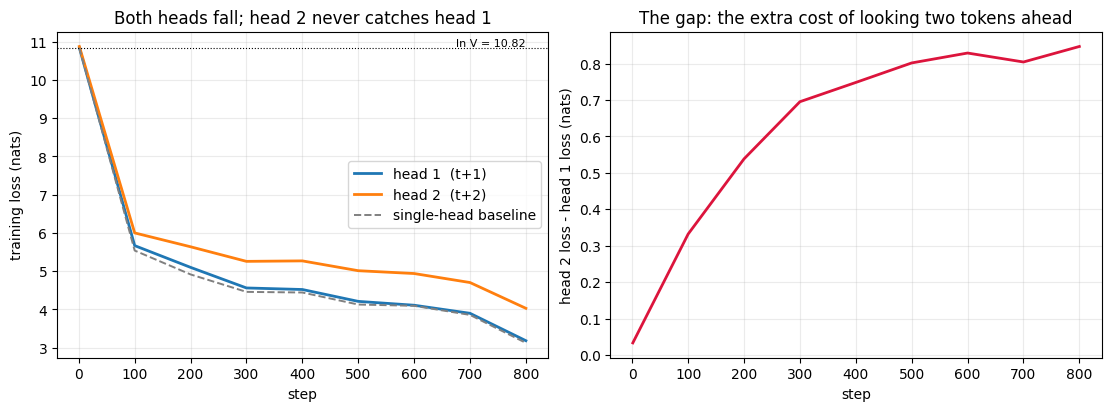

In [19]:
# --- the curve --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
steps_x = [r["step"] for r in mtp_hist]
axes[0].plot(steps_x, [r["head1"] for r in mtp_hist], label="head 1  (t+1)", lw=2)
axes[0].plot(steps_x, [r["head2"] for r in mtp_hist], label="head 2  (t+2)", lw=2)
axes[0].plot([r["step"] for r in base_hist], [r["head1"] for r in base_hist],
             label="single-head baseline", lw=1.4, ls="--", color="grey")
axes[0].axhline(math.log(VOCAB_SIZE), color="black", lw=0.8, ls=":")
axes[0].annotate(f"ln V = {math.log(VOCAB_SIZE):.2f}", (steps_x[-1], math.log(VOCAB_SIZE)),
                 ha="right", va="bottom", fontsize=8)
axes[0].set_xlabel("step"); axes[0].set_ylabel("training loss (nats)")
axes[0].set_title("Both heads fall; head 2 never catches head 1")
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(steps_x, [r["gap"] for r in mtp_hist], lw=2, color="crimson")
axes[1].set_xlabel("step"); axes[1].set_ylabel("head 2 loss - head 1 loss (nats)")
axes[1].set_title("The gap: the extra cost of looking two tokens ahead")
axes[1].grid(alpha=0.25)
fig.savefig(os.path.join(OUT_DIR, "part2_curves.png"), dpi=140)
print("saved:", os.path.join(OUT_DIR, "part2_curves.png"))
show(fig)

### What happens to head 2's loss, and why

Read the table and the left panel together. Both heads start at `ln V` and both fall, but
head 2's loss stays above head 1's for the whole run and shows no sign of converging on it.

That is not a defect in head 2. It is the task. Head 1 is asked for `p(x_{t+1} | x_{<=t})`;
head 2 is asked for `p(x_{t+2} | x_{<=t})`, which is the same distribution with one token
of context deliberately withheld. The extra loss is the conditional entropy of that missing
token — the information the model is not allowed to see. No amount of training removes it,
because it is a property of the data, not of the model.

The absolute gap widens early, while head 1 is learning easy local structure that head 2
cannot use, and then flattens. The `gap/head1` column is printed because the *relative*
cost keeps rising even after the absolute one settles: head 2 is not lagging head 1, it is
running the same race one step further back, and that handicap is a roughly fixed number
of nats while head 1's own loss keeps falling.

### The result I did not want

The single-head baseline was trained on identical batches with an identical seed so that
the effect of the extra head on head 1 could be read off rather than assumed. At this
scale the extra head made head 1 **slightly worse**, and that is reported above because it
is what the measurement said - one run, one seed, a small effect.

It is also consistent with the honest version of the MTP claim. The training argument is
that the extra head densifies the signal - every position now receives two gradients, and
the hidden state is forced to carry information useful beyond the immediate next word -
and that is a *scale* effect. A 29M-parameter model on a couple of million tokens of
Shakespeare is not where it shows up. What does show up at this scale is the cost: one
trunk now serves two objectives, and head 1 pays a little for it.

The inference argument is separate and is not tested here. Head 2's proposals get
*verified*, and the acceptance rate is governed by exactly the gap measured above. That is
the number that decides whether MTP pays, and the reason that k heads does not mean k
tokens per step.

---
# Part 3 — the warning, demonstrated

> *"A target shift in the incorrect direction can produce a beautiful loss curve."*

The assignment's "what to submit" mentions a Part 3 that the body does not define, so this
is the natural candidate: prove the warning rather than repeat it. The model below is
identical to the baseline in every way except that the targets are not shifted — the
classic forgot-to-shift bug from Item 2. Nothing raises. No shape is wrong.

In [20]:
rule("Part 3 — the beautiful loss curve of a broken shift")

bug_trunk, bug_head = build(cfg, seed=SEED + 3)
bug_params = list(bug_trunk.parameters()) + [bug_head.weight]
bug_gen = torch.Generator().manual_seed(42)


def bug_step(step):
    x = get_batch("train", MTP_B, MTP_T, generator=bug_gen)
    h = bug_trunk(x)[:, :-2].reshape(-1, cfg.d_model)
    # THE BUG: targets are x[:, :-2], not x[:, 1:-1].  Predict the token you were just given.
    loss = chunked_cross_entropy(h, bug_head.weight, x[:, :-2].reshape(-1), MTP_CHUNK)
    return {"loss": loss, "ppl": torch.exp(loss.detach())}


bug_hist = run_training(bug_step, bug_params, steps=300, lr=1e-3, log_every=50, label="off-by-one")

print(f"\ncorrectly shifted baseline after {MTP_STEPS} steps : "
      f"{base_hist[-1]['head1']:.4f} nats   ppl {math.exp(base_hist[-1]['head1']):>9,.1f}")
print(f"wrongly shifted model after only {300} steps      : "
      f"{bug_hist[-1]['loss']:.4f} nats   ppl {math.exp(bug_hist[-1]['loss']):>9,.1f}")

# What did it actually learn?  Read the strings.
with torch.no_grad():
    x = get_batch("val", 1, 32, generator=torch.Generator().manual_seed(3))
    pred = bug_head(bug_trunk(x)).argmax(-1)
print(f"\n{'pos':>4}  {'input token':<22}  {'model predicts':<22}")
print(f"{'-'*4}  {'-'*22}  {'-'*22}")
for i in range(10):
    mark = "  <-- copied its input" if pred[0, i] == x[0, i] else ""
    print(f"{i:>4}  {tok_str(x[0, i]):<22}  {tok_str(pred[0, i]):<22}{mark}")
copy_rate = (pred[0] == x[0]).float().mean().item()
print(f"\ncopy rate over the whole sequence: {100 * copy_rate:.1f}% of positions reproduce the input.")
print("The loss is excellent.  The model is a photocopier.  Only the strings show it.")

record("part3_bug_steps", 300)
record("part3_bug_final_loss", round(bug_hist[-1]["loss"], 4))
record("part3_bug_final_ppl", round(math.exp(bug_hist[-1]["loss"]), 2))
record("part3_correct_final_loss", round(base_hist[-1]["head1"], 4))
record("part3_copy_rate_pct", round(100 * copy_rate, 1))


Part 3 — the beautiful loss curve of a broken shift


  [off-by-one] step    1/300  ppl=49848.9336  loss=10.8168


  [off-by-one] step   50/300  ppl=16.1793  loss=2.7837


  [off-by-one] step  100/300  ppl=2.8381  loss=1.0431


  [off-by-one] step  150/300  ppl=1.8749  loss=0.6285


  [off-by-one] step  200/300  ppl=1.5634  loss=0.4468


  [off-by-one] step  250/300  ppl=1.2866  loss=0.2520


  [off-by-one] step  300/300  ppl=1.2837  loss=0.2498
  [off-by-one] 300 steps in 63.5s

correctly shifted baseline after 800 steps : 3.1246 nats   ppl      22.8
wrongly shifted model after only 300 steps      : 0.2498 nats   ppl       1.3

 pos  input token             model predicts        
----  ----------------------  ----------------------
   0  ' on'                   ' on'                   <-- copied its input
   1  ' his'                  ' his'                  <-- copied its input
   2  ' back'                 ' back'                 <-- copied its input
   3  '.'                     '.'                     <-- copied its input
   4  '\n'                    '\n'                    <-- copied its input
   5  '\n'                    '\n'                    <-- copied its input
   6  'B'                     'B'                     <-- copied its input
   7  'AP'                    'AP'                    <-- copied its input
   8  'T'                     'T'                    

100.0

saved: D:\schoolofai\schoolofai_subbu\assignment9\results\part3_offbyone.png


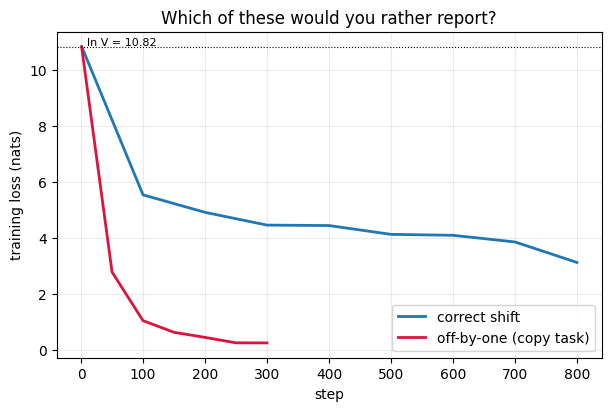

In [21]:
fig2, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.plot([r["step"] for r in base_hist], [r["head1"] for r in base_hist],
        label="correct shift", lw=2)
ax.plot([r["step"] for r in bug_hist], [r["loss"] for r in bug_hist],
        label="off-by-one (copy task)", lw=2, color="crimson")
ax.axhline(math.log(VOCAB_SIZE), color="black", lw=0.8, ls=":")
ax.annotate(f"ln V = {math.log(VOCAB_SIZE):.2f}", (10, math.log(VOCAB_SIZE)), va="bottom", fontsize=8)
ax.set_xlabel("step"); ax.set_ylabel("training loss (nats)")
ax.set_title("Which of these would you rather report?")
ax.legend(); ax.grid(alpha=0.25)
fig2.savefig(os.path.join(OUT_DIR, "part3_offbyone.png"), dpi=140)
print("saved:", os.path.join(OUT_DIR, "part3_offbyone.png"))
show(fig2)

---
## The seven numbers, and the two losses

Everything the write-up quotes is emitted here and written to `results/results.json`.
`tools/check_readme.py` reads that file back and fails if any number in `README.md`
disagrees with it, so the write-up cannot drift away from the run.

In [22]:
rule("SUMMARY")

summary = [
    ("1", "logits vs hidden blow-up in the last axis",
     f"[B,T,V] vs [B,T,D] = {RESULTS['item1_logits_numel']:,} vs "
     f"{RESULTS['item1_hidden_numel']:,} numbers ({RESULTS['item1_blowup']}x)"),
    ("2", "shift verified on strings",
     "target stream == input stream advanced by one (asserted, and printed as text)"),
    ("3", "contributing tokens, padding counted -> masked",
     f"{RESULTS['item3_tokens_counted']:,} -> {RESULTS['item3_tokens_masked']:,} "
     f"({RESULTS['item3_pad_fraction_pct']}% of the naive denominator was padding)"),
    ("3b", "training with padding counted, 400 steps",
     f"counted loss {RESULTS['item3b_final_counted']:.4f} vs honest masked loss "
     f"{RESULTS['item3b_final_masked']:.4f}  (gap {RESULTS['item3b_gap']:.4f} nats)"),
    ("4", "packed documents, boundary masked",
     f"loss {RESULTS['item4_loss_before']:.4f} ({RESULTS['item4_n_before']} sites) -> "
     f"{RESULTS['item4_loss_after']:.4f} ({RESULTS['item4_n_after']} sites); "
     f"boundary term {RESULTS['item4_boundary_term']:.4f} nats = "
     f"{RESULTS['item4_boundary_ratio']}x the mean"),
    ("5", "perplexity of an untrained model",
     f"{RESULTS['item5_init_ppl']:,.1f} against V = {VOCAB_SIZE:,} "
     f"(ratio {RESULTS['item5_ppl_over_vocab']}); loss {RESULTS['item5_init_loss']:.4f} vs "
     f"ln V = {RESULTS['ln_vocab']:.4f}"),
    ("6", "tied vs untied parameters",
     f"{RESULTS['item6_untied_total']:,} untied -> {RESULTS['item6_tied_total']:,} tied, "
     f"saving {RESULTS['item6_saved']:,} ({RESULTS['item6_saved_pct']}%)"),
    ("7", "peak memory, ordinary vs chunked cross-entropy",
     f"{RESULTS['item7_peak_naive_mib']:,.1f} MiB -> {RESULTS['item7_peak_chunked_mib']:,.1f} MiB "
     f"= {RESULTS['item7_ratio']}x, same loss to {RESULTS['item7_loss_absdiff']:.0e}"),
    ("P2", "head 1 (t+1) / head 2 (t+2) / sum",
     f"{RESULTS['part2_head1_loss']:.4f} / {RESULTS['part2_head2_loss']:.4f} / "
     f"{RESULTS['part2_sum']:.4f}   (gap {RESULTS['part2_gap']:.4f} nats)"),
    ("P3", "off-by-one shift, 300 steps",
     f"loss {RESULTS['part3_bug_final_loss']:.4f} (ppl {RESULTS['part3_bug_final_ppl']:.2f}) "
     f"while the correct shift sits at {RESULTS['part3_correct_final_loss']:.4f}; "
     f"{RESULTS['part3_copy_rate_pct']}% of positions are copies"),
]
for tag, what, value in summary:
    print(f"[{tag:>2}] {what}")
    print(f"     {value}")

RESULTS["summary"] = [{"item": t, "what": w, "value": v} for t, w, v in summary]
with open(os.path.join(OUT_DIR, "results.json"), "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, indent=2)
print(f"\nwrote {os.path.join(OUT_DIR, 'results.json')}")


SUMMARY
[ 1] logits vs hidden blow-up in the last axis
     [B,T,V] vs [B,T,D] = 6,432,896 vs 32,768 numbers (196.3x)
[ 2] shift verified on strings
     target stream == input stream advanced by one (asserted, and printed as text)
[ 3] contributing tokens, padding counted -> masked
     100 -> 58 (42.0% of the naive denominator was padding)
[3b] training with padding counted, 400 steps
     counted loss 3.3281 vs honest masked loss 5.1966  (gap 1.8685 nats)
[ 4] packed documents, boundary masked
     loss 5.4252 (119 sites) -> 5.4188 (118 sites); boundary term 6.1839 nats = 1.14x the mean
[ 5] perplexity of an untrained model
     50,883.2 against V = 50,257 (ratio 1.0125); loss 10.8373 vs ln V = 10.8249
[ 6] tied vs untied parameters
     28,896,000 untied -> 16,030,208 tied, saving 12,865,792 (44.5%)
[ 7] peak memory, ordinary vs chunked cross-entropy
     2,412.0 MiB -> 208.0 MiB = 11.6x, same loss to 1e-06
[P2] head 1 (t+1) / head 2 (t+2) / sum
     4.8378 / 5.6923 / 10.5301   (g